In [58]:
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import json
from matplotlib.image import imread
from glob import glob
from pathlib import Path

In [59]:
!mkdir -p data/Wu2021
%cd data/Wu2021

/Users/student/Library/CloudStorage/OneDrive-UniversityofPittsburgh/code/stan/notebooks/breast_cancer/data/Wu2021/data/Wu2021


Download all of the data

In [23]:
!curl -O -J https://zenodo.org/record/4739739/files/spatial.tar.gz
!curl -O -J https://zenodo.org/record/4739739/files/filtered_count_matrices.tar.gz
!curl -O -J https://zenodo.org/record/4739739/files/metadata.tar.gz

!tar xvf metadata.tar.gz
!tar xvf filtered_count_matrices.tar.gz
!tar xvf spatial.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 51.7M  100 51.7M    0     0  3853k      0  0:00:13  0:00:13 --:--:-- 4223k3865k      0  0:00:13  0:00:13 --:--:-- 4186k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  148M  100  148M    0     0  1748k      0  0:01:26  0:01:26 --:--:-- 1598k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  212k  100  212k    0     0   122k      0  0:00:01  0:00:01 --:--:--  122k
x metadata/
x metadata/1142243F_metadata.csv
x metadata/1160920F_metadata.csv
x metadata/CID4290_metadata.csv
x metadata/CID4465_metadata.csv
x metadata/CID44971_metadata.csv
x metadata/CID4535_metadata.csv
x filtered_count_matrices/
x filtered

open single cell data in scanpy

In [2]:

%cd data/Wu2021
!curl -O -J https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz
!tar xvf GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz

path="Wu_etal_2021_BRCA_scRNASeq/"
adata_scRNA=sc.read_mtx(path+"count_matrix_sparse.mtx").transpose()
adata_scRNA.obs=pd.read_csv(path+"metadata.csv", index_col=0)
adata_scRNA.var_names=pd.read_csv(path+"count_matrix_genes.tsv", index_col=0, header=None).index.to_list()
adata_scRNA.write_h5ad("scRNA.h5ad")

[Errno 2] No such file or directory: 'data/Wu2021'
/Users/aprilsagan/OneDrive - University of Pittsburgh/code/stan/notebooks/breast_cancer/data/Wu2021
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  532M  100  532M    0     0  2408k      0  0:03:46  0:03:46 --:--:-- 2890k 0  3214k      0  0:02:49  0:00:24  0:02:25 3882k      0  0:03:36  0:02:37  0:00:59 2605k0  2482k      0  0:03:39  0:03:00  0:00:39 1813k  0  2388k      0  0:03:48  0:03:12  0:00:36  800k
x Wu_etal_2021_BRCA_scRNASeq/
x Wu_etal_2021_BRCA_scRNASeq/count_matrix_sparse.mtx
x Wu_etal_2021_BRCA_scRNASeq/count_matrix_genes.tsv
x Wu_etal_2021_BRCA_scRNASeq/count_matrix_barcodes.tsv
x Wu_etal_2021_BRCA_scRNASeq/metadata.csv


... storing 'orig.ident' as categorical
... storing 'subtype' as categorical
... storing 'celltype_subset' as categorical
... storing 'celltype_minor' as categorical
... storing 'celltype_major' as categorical


<AxesSubplot:xlabel='orig.ident', ylabel='nFeature_RNA'>

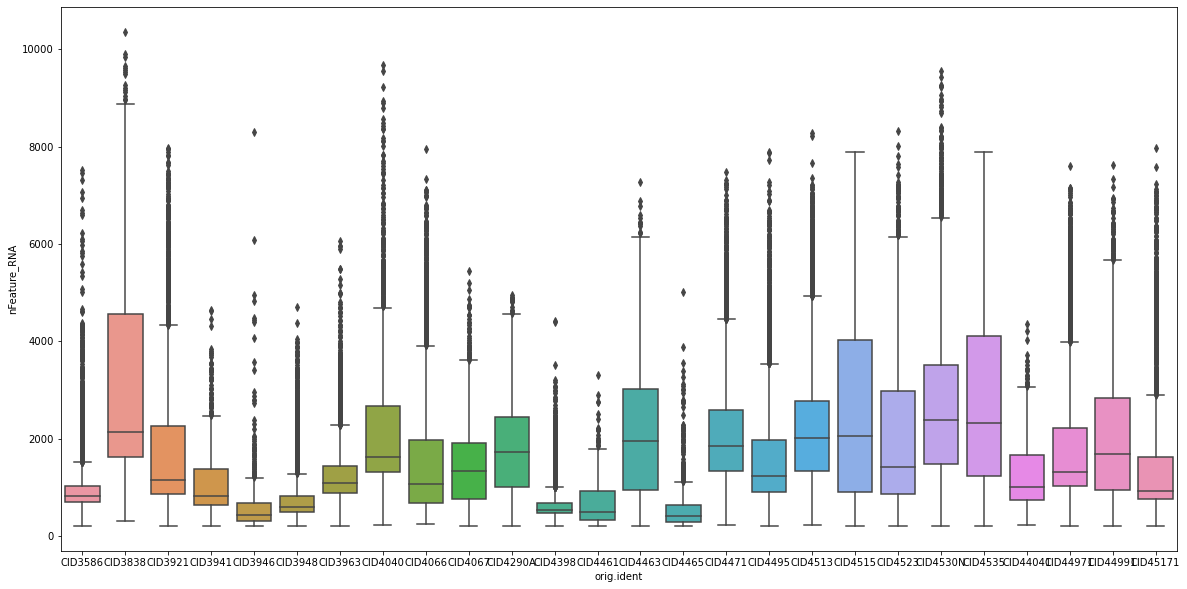

In [45]:
adata_scRNA.obs
import seaborn as sns
from matplotlib import pyplot as plt
plt.figure(figsize=(20,10))
sns.boxplot(x="orig.ident", y="nFeature_RNA", data=adata_scRNA.obs)

Prep the single cell reference libraries for stereoscope

In [5]:
import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np

def subsample_celltype(adata, obs_name="cell_types", n_cells=700, random_state=0):
    '''
    Subsets data set to contain no more than a given amount of any one cell type.
    Parameters
    ----------
    adata : AnnData
        input dataset
    obs_name : str, optional
        field in `adata.obs` corresponding to cell types.  Default: "cell_types"
    n_cells : int, optional
        maximum number of cells for any cell type.
    random_state : int, optional
        seed used for reproducibility.
    Returns
    -------
    adata : AnnData
        subsampled dataset
    '''

    adatas=dict()
    for ct in np.unique(adata.obs[obs_name]):
        adatas[ct]=adata[(adata.obs[obs_name] == ct)]
        if adatas[ct].n_obs>n_cells:
            adatas[ct]=sc.pp.subsample(adatas[ct], n_obs=n_cells, random_state=random_state, copy=True)
    return ad.concat(adatas, label="cell_types")

adata_scRNA=sc.read_h5ad("scRNA.h5ad")

genes_for_stsc=np.intersect1d(
    adata_scRNA.var_names,
    pd.read_excel(
        "https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-021-26271-2/MediaObjects/41467_2021_26271_MOESM16_ESM.xlsx",
        header=None
    )[0].to_list()
)

adata_scRNA.obs['subtype']=adata_scRNA.obs['subtype'].cat.rename_categories({"HER2+": "HER2", "ER+": "ER"})

adata_ER=adata_scRNA[
    adata_scRNA.obs.query("subtype == 'ER'").index,
    genes_for_stsc
]
adata_ER=subsample_celltype(adata_ER, obs_name="celltype_major", n_cells=500)
adata_ER.write_h5ad("sc_ER.h5ad")


adata_TNBC=adata_scRNA[
    adata_scRNA.obs.query("subtype == 'TNBC'").index,
    genes_for_stsc
]
adata_TNBC=subsample_celltype(adata_TNBC,obs_name="celltype_major", n_cells=500)
adata_TNBC.write_h5ad("sc_TNBC.h5ad")

adata_HER2=adata_scRNA[
    adata_scRNA.obs.query("subtype == 'HER2'").index,
    genes_for_stsc
]
adata_HER2=subsample_celltype(adata_HER2,obs_name="celltype_major", n_cells=500)
adata_HER2.write_h5ad("sc_HER2.h5ad")



adata_ER=adata_scRNA[
    adata_scRNA.obs.query("subtype == 'ER'").index,
    genes_for_stsc
]
adata_ER=subsample_celltype(adata_ER, obs_name="celltype_minor", n_cells=500)
adata_ER.write_h5ad("sc_ER_minor.h5ad")

adata_TNBC=adata_scRNA[
    adata_scRNA.obs.query("subtype == 'TNBC'").index,
    genes_for_stsc
]
adata_TNBC=subsample_celltype(adata_TNBC,obs_name="celltype_minor", n_cells=500)
adata_TNBC.write_h5ad("sc_TNBC_minor.h5ad")

adata_HER2=adata_scRNA[
    adata_scRNA.obs.query("subtype == 'HER2'").index,
    genes_for_stsc
]
adata_HER2=subsample_celltype(adata_HER2,obs_name="celltype_minor", n_cells=500)
adata_HER2.write_h5ad("sc_HER2_minor.h5ad")

/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1220: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'orig.ident' as categorical
/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1220: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'celltype_subset' as categorical
/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:1220: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed 

open ST data

In [39]:
for sample_id in ["1142243F", "1160920F", "CID4290", "CID4535", "CID4465", "CID44971"]:
    library_id=sample_id
    for f in glob("filtered_count_matrices/"+sample_id+"_filtered_count_matrix/*.gz"):
        g=f[0:-3]
        !mv $f $g
    adata=sc.read_mtx("filtered_count_matrices/"+sample_id+"_filtered_count_matrix/matrix.mtx").T
    with open("filtered_count_matrices/"+sample_id+"_filtered_count_matrix/barcodes.tsv", "r") as f:
        adata.obs_names=f.read().split("\n")[0:-1]
    with open("filtered_count_matrices/"+sample_id+"_filtered_count_matrix/features.tsv", "r") as f:
        adata.var_names=f.read().split("\n")[0:-1]

    adata.uns["spatial"] = dict()

    adata.uns["spatial"][library_id] = dict()
    spatial_path='spatial/'+sample_id+'_spatial/'
    files = dict(
        tissue_positions_file=spatial_path+'tissue_positions_list.csv',
        scalefactors_json_file=spatial_path+'scalefactors_json.json',
        hires_image=spatial_path+'tissue_hires_image.png',
        lowres_image=spatial_path+'tissue_lowres_image.png',
    )

    adata.uns["spatial"][library_id]['images'] = dict()
    for res in ['hires', 'lowres']:
        adata.uns["spatial"][library_id]['images'][res] = imread(
            str(files[f'{res}_image'])
        )

    # read json scalefactors
    adata.uns["spatial"][library_id]['scalefactors'] = json.loads(
        Path(files['scalefactors_json_file']).read_bytes()
    )

    # read coordinates
    positions = pd.read_csv(files['tissue_positions_file'], header=None)
    positions.columns = [
        'barcode',
        'in_tissue',
        'array_row',
        'array_col',
        'pxl_col_in_fullres',
        'pxl_row_in_fullres',
    ]
    positions.index = positions['barcode']

    adata.obs = adata.obs.join(positions, how="left")

    adata.obsm['spatial'] = adata.obs[
        ['pxl_row_in_fullres', 'pxl_col_in_fullres']
    ].to_numpy()
    adata.obs.drop(
        columns=['barcode', 'pxl_row_in_fullres', 'pxl_col_in_fullres'],
        inplace=True,
    )
    adata.write_h5ad("st_"+sample_id+".h5ad")

Stereoscope cell type classification


In [10]:
# !git clone https://github.com/almaan/stereoscope
#
# %cd stereoscope
# !./setup.py install
# %cd ..

!mkdir stsc
!mkdir stsc/ER/
!stereoscope run --sc_cnt sc_ER.h5ad --label_colname celltype_major --st_cnt st_CID4535.h5ad -o stsc/ER/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/ER/R*.tsv stsc/ER/logits*.tsv --st_cnt st_CID4290.h5ad -o stsc/ER/ -ste 50000 -stb 2048 --gpu

!mkdir stsc/TNBC/
!stereoscope run --sc_cnt sc_TNBC.h5ad --label_colname celltype_major --st_cnt st_CID4465.h5ad -o stsc/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/TNBC/R*.tsv stsc/TNBC/logits*.tsv --st_cnt st_CID44791.h5ad -o stsc/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/TNBC/R*.tsv stsc/TNBC/logits*.tsv --st_cnt st_1142243F.h5ad -o stsc/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/TNBC/R*.tsv stsc/TNBC/logits*.tsv --st_cnt st_1160920F.h5ad -o stsc/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu

!mkdir stsc/celltype_minor/
!mkdir stsc/celltype_minor/ER/
!stereoscope run --sc_cnt sc_ER_minor.h5ad --label_colname celltype_minor --st_cnt st_CID4535.h5ad -o stsc/celltype_minor/ER/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/celltype_minor/ER/R*.tsv stsc/celltype_minor/ER/logits*.tsv --st_cnt st_CID4290.h5ad -o stsc/celltype_minor/ER/ -ste 50000 -stb 2048 --gpu

!mkdir stsc/celltype_minor/TNBC/
!stereoscope run --sc_cnt sc_TNBC_minor.h5ad --label_colname celltype_minor --st_cnt st_CID4465.h5ad -o stsc/celltype_minor/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/celltype_minor/TNBC/R*.tsv stsc/celltype_minor/TNBC/logits*.tsv --st_cnt st_CID44791.h5ad -o stsc/celltype_minor/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/celltype_minor/TNBC/R*.tsv stsc/celltype_minor/TNBC/logits*.tsv --st_cnt st_1142243F.h5ad -o stsc/celltype_minor/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu
!stereoscope run --sc_fit stsc/celltype_minor/TNBC/R*.tsv stsc/celltype_minor/TNBC/logits*.tsv --st_cnt st_1160920F.h5ad -o stsc/celltype_minor/TNBC/ -ste 50000 -sce 50000 -stb 2048 -scb 2048 --gpu

mkdir: stsc: File exists
mkdir: stsc/ER/: File exists
/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 4.0.0-unsupported is an invalid version and will not be supported in a future release
  warnings.warn(
/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 4.0.0-unsupported is an invalid version and will not be supported in a future release
  warnings.warn(
Traceback (most recent call last):
  File "/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/pkg_resources/__init__.py", line 581, in _build_master
    ws.require(__requires__)
  File "/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/pkg_resources/__init__.py", line 909, in require
    needed = self.resolve(parse_requirements(requirements))
  File "/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/pkg_resources/__init__.py", line 800, in resolve
    raise Ver

Read stereoscope results and store into st data, along with meta data

| Case ID | Gender | Age | Grade | Cancer Type | ER     | PR     | HER2 IHC | HER2 ISH (ratio) | Ki67 | Subtype by IHC | Treatment status | Details of treatment | Notable Pathological features                                                                                         | Stage                   |
| ------- | ------ | --- | ----- | ----------- | ------ | ------ | -------- | ---------------- | ---- | -------------- | ---------------- | -------------------- | --------------------------------------------------------------------------------------------------------------------- | ----------------------- |
| 4290    | Female | 88  | 2     | IDC         | 90% 3+ | 30% 2+ | 1+       | Non-Amplified    | 0.1  | ER+            | Naïve            | \-                   | Locally advanced, skin and chest wall muscle involvement.                                                             | pT4b, Nx                |
| 4497-1  | Female | 49  | 3     | IDC         | 0      | 0      | 0        | Non-Amplified    | 0.4  | TNBC           | Naïve            | \-                   | Highly atypical cells with circumscribed periphery, associated high grade DCIS and LVI. Accompanying lymphoid stroma. | pT2, N1a, Mx            |
| 4465    | Female | 54  | 3     | IDC         | 0      | 0      | 0        | Non-Amplified    | 0.7  | TNBC           | Naïve            | \-                   | Basal phenotype - patchy CK5/6 and p63 positivity. Associated high grade DCIS at periphery of tumour mass.            | PT2, N0(sn) Mx          |
| 4535    | Female | 47  | 2     | ILC         | 95% 3+ | 70% 2+ | 2+       | Non-Amplified    | 0.1  | ER+            | Naïve            | \-                   | \-                                                                                                                    | pT2, pN0 (i+),Stage IIB |


In [10]:
from glob import glob
for sample in ["1142243F", "1160920F", "CID4290", "CID4535", "CID4465", "CID44971"]:
    ct=pd.read_csv(
        [*glob("stsc/TNBC/st_"+sample+"/W*.tsv"),*glob("stsc/ER/st_"+sample+"/W*.tsv")][0],
        sep='\t',index_col=0)

    adata=sc.read_h5ad("st_"+sample+".h5ad")
    metadata_df=pd.read_csv("metadata/"+sample+"_metadata.csv", index_col=0)

    adata.obs["subtype"]=metadata_df["subtype"]
    adata.obs["pathology"]=metadata_df["Classification"]
    adata.obs["sample"]=sample
    adata.obs["replicate"]=sample
    adata.obs["source"]="Wu2021"
    adata.obs["ER"]= [x=="ER" for x in adata.obs["subtype"]]
    adata.obs["HER2"]=False # all samples are HER2 - in this dataset.
    adata.obs["PR"]= adata.obs["ER"] # All ER+ samples are also PR+ in this dataset.

    adata.layers["raw_counts"]=adata.X

    adata.obs_names=sample+"_"+adata.obs_names
    ct.index=adata.obs_names
    adata.obsm["celltype_major"]=ct


    ct_minor_file=[*glob("stsc/celltype_minor/TNBC/st_"+sample+"/W*.tsv"),*glob("stsc/celltype_minor/ER/st_"+sample+"/W*.tsv")]
    if len(ct_minor_file)>0:
        ct_minor=pd.read_csv(
            ct_minor_file[0],
            sep='\t',index_col=0)
        ct_minor.index=adata.obs_names
        adata.obsm["celltype_minor"]=ct_minor

    adata.write_h5ad(sample+".h5ad")

In [ ]:
import squidpy
sc.pp.log1p(adata)
sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["Normal Epithelial", "EPCAM"],
              alpha_img=0)

sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["T-cells", "CD3D"],
              alpha_img=0)

sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["Plasmablasts", "JCHAIN"],
              alpha_img=0)
sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["B-cells", "MS4A1"],
              alpha_img=0)
sc.pl.spatial(squidpy.pl.extract(adata, "celltype_major"),
              color=["Endothelial", "PECAM1"],
              alpha_img=0)